# Chapter 4 - Modeling Volatility with GARCH 

### 1. Get more pretty graphs

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(
    context="talk",
    style="whitegrid",
    palette="colorblind",
    color_codes=True,
    rc={"figure.figsize":[12,8]}
)

### 2. Import our final and clean data 

In [22]:
import pandas as pd

df_final = pd.read_csv(
    "mxn_forecasting_clean.csv",
    index_col=0,
    parse_dates=True
)

df_final.head()

,mxn_usd,oil_prices,usd_mxn_returns,oil_returns,vix,fed_funds_rate,industrial_activity,inflation_rate,banxico_rate
2008-01-22,10.925,89.64,NaN,NaN,31.010000,3.94,100.9807,3.704372,7.5
2008-01-23,10.893,87.65,-0.002933,-0.022450,29.020000,3.94,100.9807,3.704372,7.5
2008-01-24,10.862,89.98,-0.002850,0.026236,27.780001,3.94,100.9807,3.704372,7.5
2008-01-25,10.866,90.37,0.000368,0.004325,29.080000,3.94,100.9807,3.704372,7.5
2008-01-28,10.863,90.99,-0.000276,0.006837,27.780001,3.94,100.9807,3.704372,7.5


### 3. Returns Plot

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

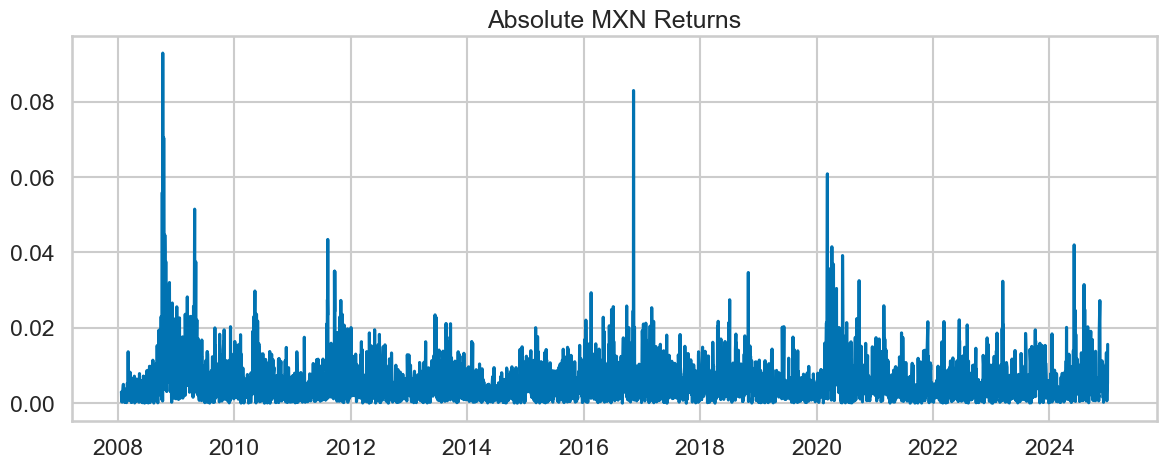

In [25]:
plt.figure(figsize=(14,5))

plt.plot(
    df_final.index,
    abs(df_final["usd_mxn_returns"])
)

plt.title("Absolute MXN Returns")
plt.show()

The returns plot displays the absolute daily returns of the USD/MXN exchange rate over the sample period. The series exhibits noticeable fluctuations in volatility, with periods of relative stability interrupted by episodes of substantial market turbulence. Pronounced spikes are observed during major economic and financial disruptions, including the 2008–2009 Global Financial Crisis, the uncertainty surrounding U.S.–Mexico trade negotiations in 2016–2017, and the COVID-19 pandemic in 2020. These episodes reflect heightened uncertainty in financial markets and increased pressure on the Mexican peso. The persistence of large fluctuations over consecutive periods suggests that exchange-rate volatility is not constant over time, highlighting the importance of accounting for changing risk conditions when modelling exchange-rate dynamics.

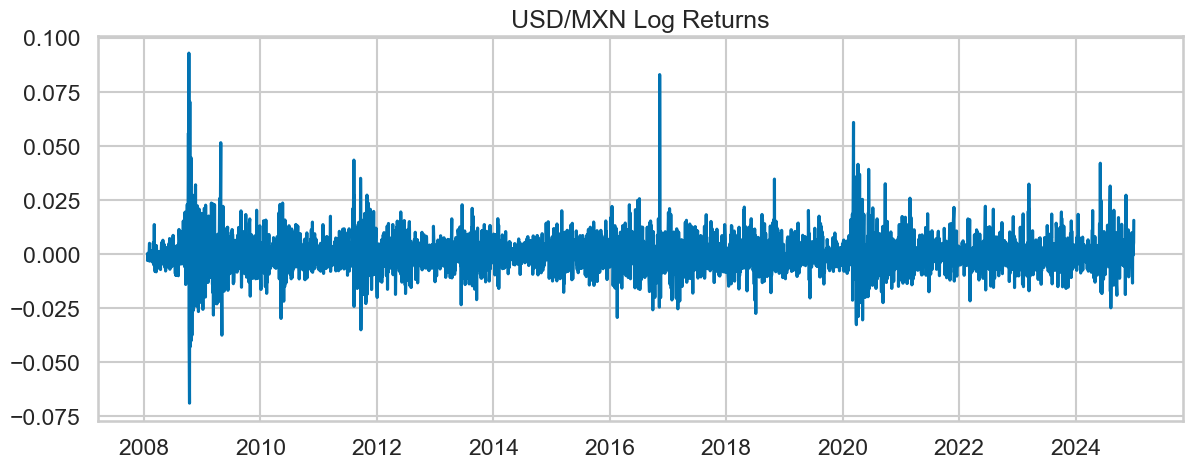

In [26]:
plt.figure(figsize=(14,5))
plt.plot(df_final["usd_mxn_returns"])
plt.title("USD/MXN Log Returns")
plt.show()

Positive and negative returns are observed throughout the sample period, indicating that the USD/MXN exchange rate experienced both appreciation and depreciation episodes. The return series fluctuates around zero, suggesting the absence of a persistent directional trend in daily exchange-rate movements. Large positive and negative spikes are concentrated around major economic and financial events.

### 4. Squared Returns Plot

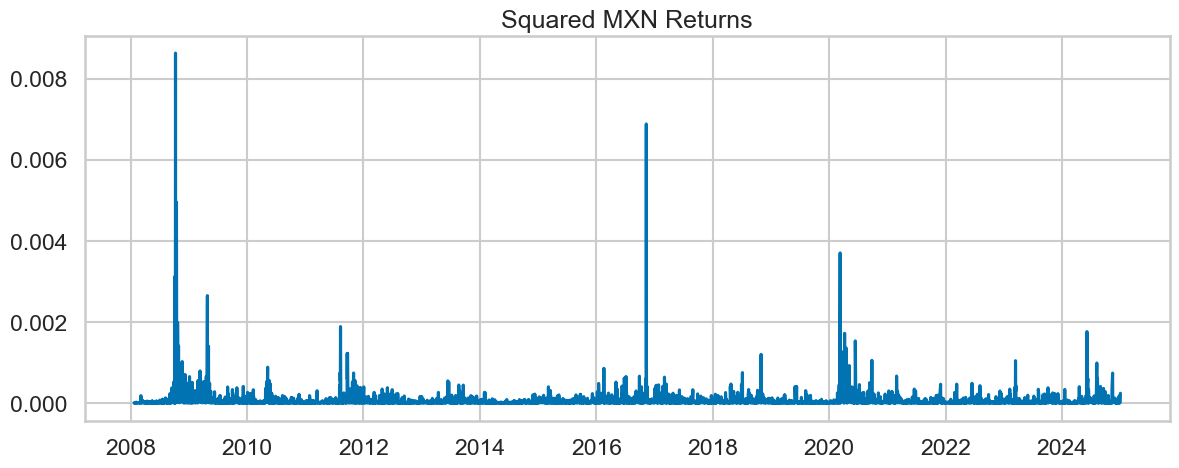

In [27]:
plt.figure(figsize=(14,5))
plt.plot(df_final["usd_mxn_returns"]**2)
plt.title("Squared MXN Returns")
plt.show()

### 5. ACF of Returns

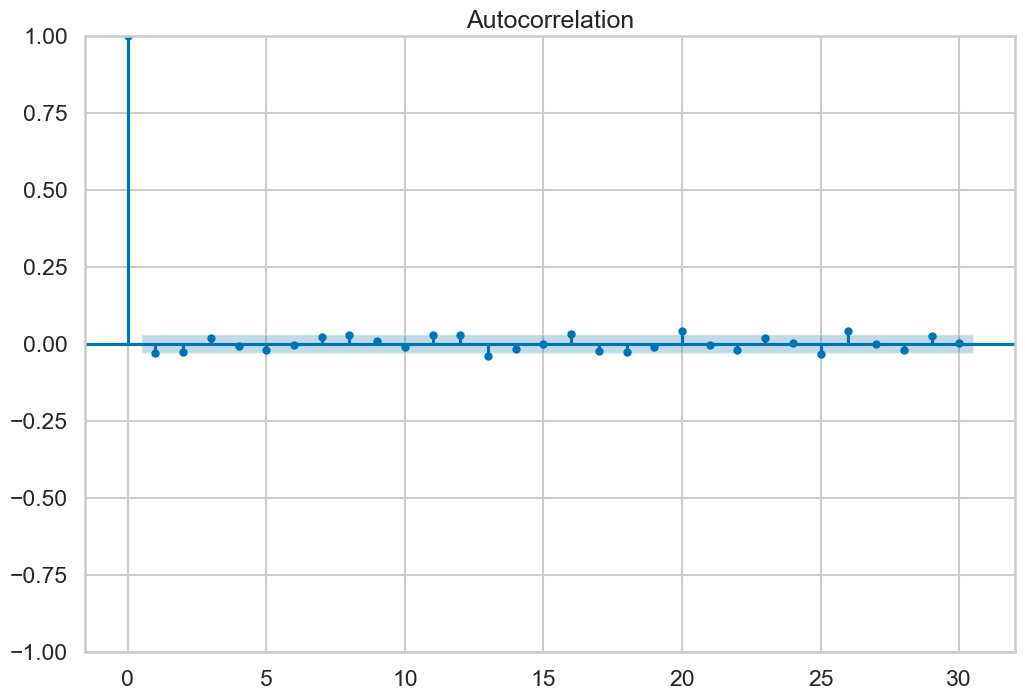

In [32]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(
    df_final["usd_mxn_returns"].dropna(),
    lags=30
)
plt.show()

The ACF of MXN/USD log returns shows that autocorrelations at all lags are close to zero and remain within the 95% confidence bands. This suggests that returns do not exhibit significant serial dependence and are therefore largely unpredictable. The result is consistent with the weak-form Efficient Market Hypothesis, according to which past returns contain little information about future returns.

### 6. ACF of Squared Returns

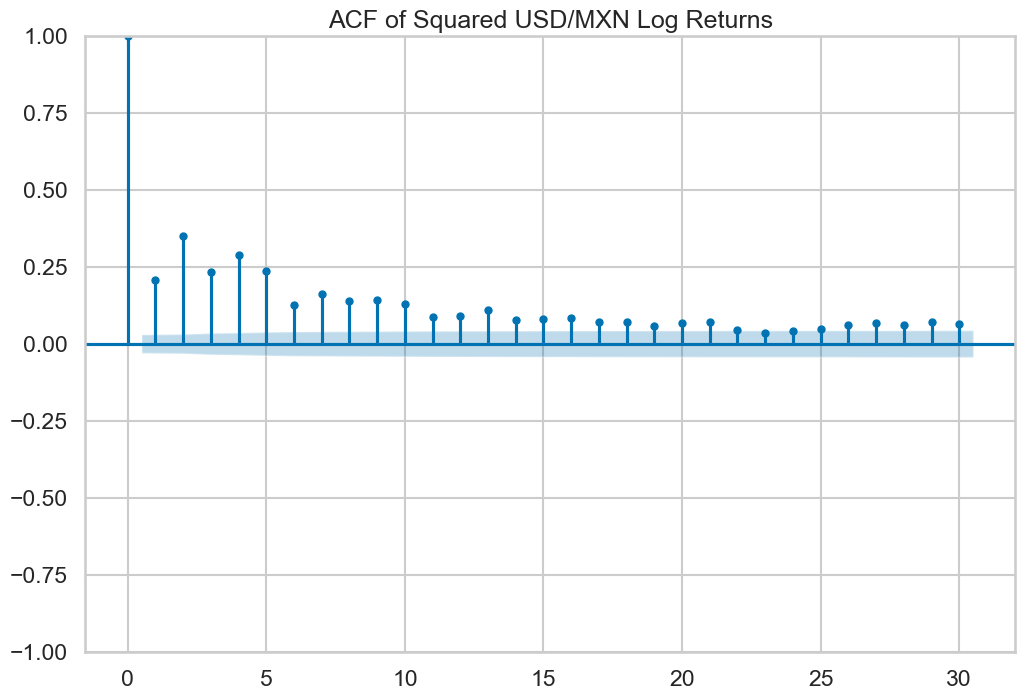

In [33]:
plot_acf(
    df_final["usd_mxn_returns"].dropna()**2,
    lags=30
)

plt.title("ACF of Squared USD/MXN Log Returns")
plt.show()

The ACF of squared returns exhibits significant positive autocorrelation across multiple lags, indicating volatility persistence and volatility clustering. This suggests that while the direction of returns is unpredictable, the magnitude of returns (volatility) contains a predictable component.

### 7.  Modeling  volatility with GARCH model

Some Insights: 
    - The autocorrelation function of returns is approximately zero, suggesting that returns behave like a white noise process and do not exhibit predictability.
    - The positive autocorrelation observed in squared returns indicates persistent volatility dynamics, which is a common characteristic of financial time series.
    - The Jarque–Bera test strongly rejects normality, indicating that the return series is characterized by non-normal behavior and fat tails. 
    - The persistence of positive and statistically significant autocorrelation coefficients in squared returns provides strong evidence of conditional heteroskedasticity.
    - The empirical results indicate that USD/MXN returns are not predictable in their mean process, as evidenced by the absence of significant autocorrelation in returns.


In [18]:
!pip install arch

  Obtaining dependency information for arch from https://files.pythonhosted.org/packages/44/b5/8f04a871c2e0f94430c15d313f88fe7808d80c4752b0ebdeadfec21dec8e/arch-8.0.0-cp311-cp311-macosx_10_9_x86_64.whl.metadata
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 940.4/940.4 kB 3.8 MB/s eta 0:00:00a 0:00:01m


## 1. GARCH(1,1) Estimation 

In [34]:
from arch import arch_model

returns = 100 * df_final["usd_mxn_returns"].dropna()

garch_model = arch_model(
    returns,
    mean="Zero",
    vol="GARCH",
    p=1,
    q=1,
    dist="t"   #Strongly recommend student-t because Jaque Bera already reject normality 
)

garch_fit = garch_model.fit(disp="off")

print(garch_fit.summary())

                          Zero Mean - GARCH Model Results                           
Dep. Variable:              usd_mxn_returns   R-squared:                       0.000
Mean Model:                       Zero Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -4620.18
Distribution:      Standardized Student's t   AIC:                           9248.36
Method:                  Maximum Likelihood   BIC:                           9273.77
                                              No. Observations:                 4245
Date:                      Sun, May 31 2026   Df Residuals:                     4245
Time:                              19:09:17   Df Model:                            0
                              Volatility Model                              
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
omeg

## 2. Conditional Volatility

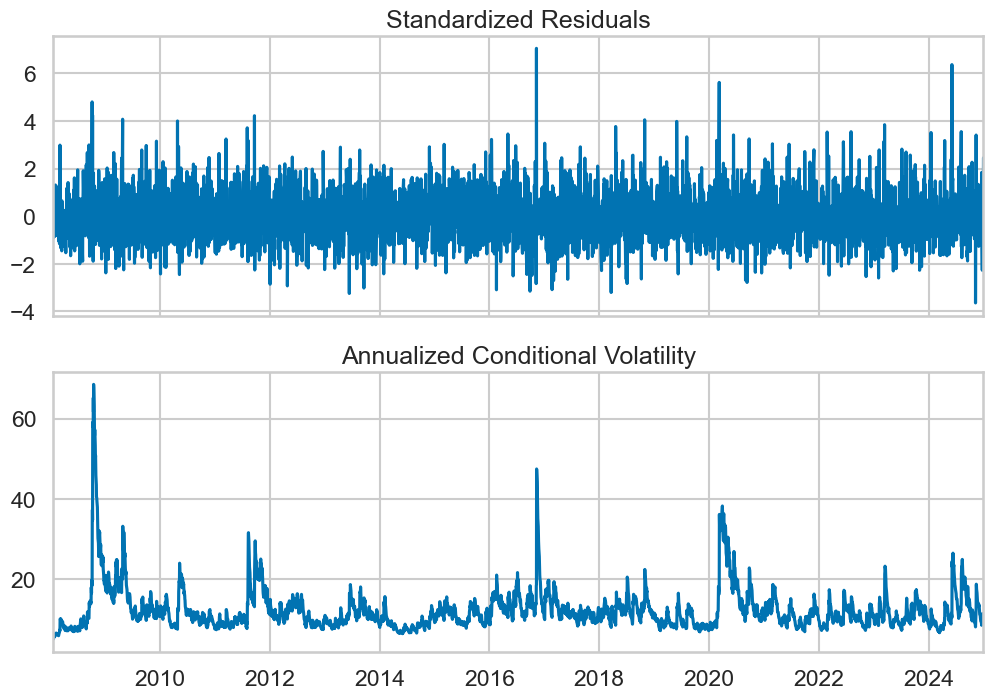

In [35]:
garch_fit.plot(annualize="D")
plt.show()

## 3. Forecasting Volatility

In [36]:
split_date = "2021-01-01"

train = returns.loc[:split_date]
test = returns.loc[split_date:]

In [37]:
model = arch_model(
    train,
    mean="Zero",
    vol="GARCH",
    p=1,
    q=1,
    dist="t"
)

fit = model.fit(disp="off")

1. CREATE AND INSPECT THE ANALYTICAL FORECAST

In [39]:
forecast_analytical = fit.forecast(
    horizon=5,
    method="analytic",
    reindex=False
)

forecast_analytical.variance.tail()

,h.1,h.2,h.3,h.4,h.5
2020-12-31,0.4775,0.482022,0.486486,0.490892,0.49524


<Axes: title={'center': 'Analytical Volatility Forecast'}>

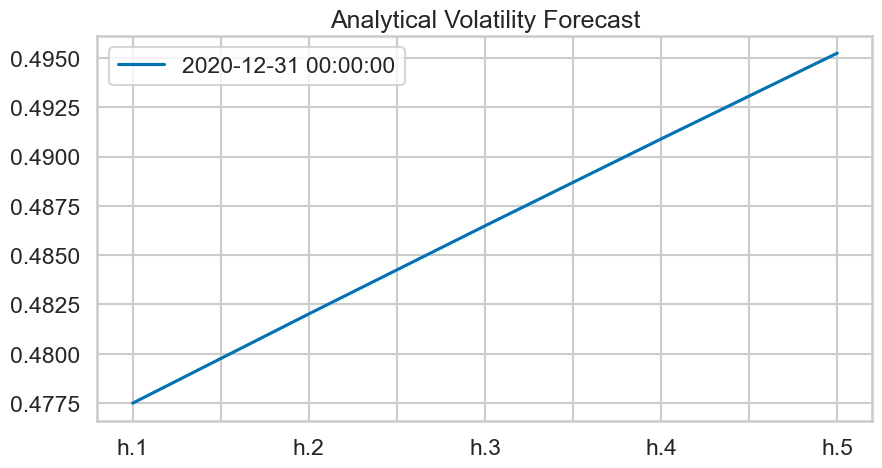

In [40]:
forecast_analytical.variance.T.plot(
    figsize=(10,5),
    title="Analytical Volatility Forecast"
)

In [41]:
import matplotlib.pyplot as plt
plt.show()

2. FITTED MODEL FORECAST

In [49]:
# The fitted model is stored in 'fit'
fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                          Zero Mean - GARCH Model Results                           
====================================================================================
Dep. Variable:              usd_mxn_returns   R-squared:                       0.000
Mean Model:                       Zero Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -3588.64
Distribution:      Standardized Student's t   AIC:                           7185.27
Method:                  Maximum Likelihood   BIC:                           7209.61
                                              No. Observations:                 3245
Date:                      Sun, May 31 2026   Df Residuals:                     3245
Time:                              19:13:17   Df Model:                            0
                              Volatility Model                              
============================================================================
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
omega          0.0107  3.848e-03      2.791  5.262e-03 [3.196e-03,1.828e-02]
alpha[1]       0.0972  2.019e-02      4.815  1.469e-06   [5.765e-02,  0.137]
beta[1]        0.8898  2.249e-02     39.560      0.000     [  0.846,  0.934]
                              Distribution                              
========================================================================
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
nu             8.5746      1.226      6.997  2.622e-12 [  6.173, 10.977]
========================================================================

Covariance estimator: robust
"""

3. CREATE AND INSPECT THE SIMULATION FORECAST

In [43]:
forecast_simulation = fit.forecast(
    horizon=5,
    method="simulation",
    simulations=1000,
    reindex=False
)

forecast_simulation.variance.tail()

,h.1,h.2,h.3,h.4,h.5
2020-12-31,0.4775,0.47893,0.481076,0.488516,0.498016


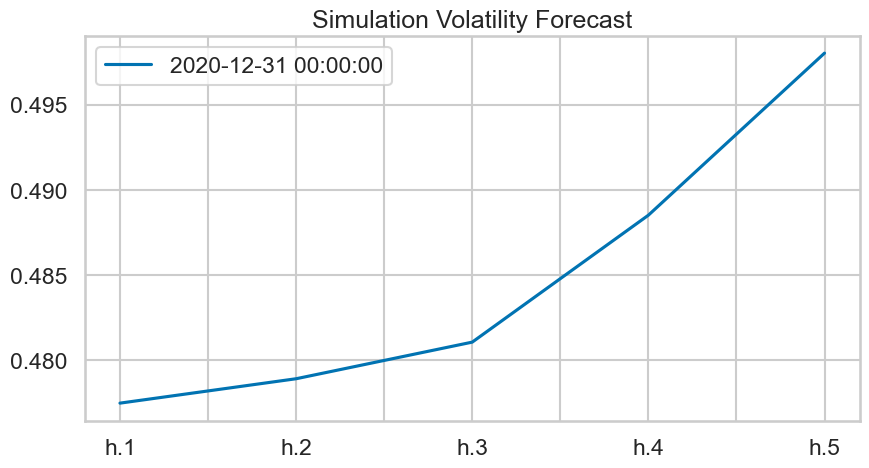

In [44]:
forecast_simulation.variance.T.plot(
    figsize=(10,5),
    title="Simulation Volatility Forecast"
)

plt.show()

4.CREATE AND INSPECT THE BOOTSTRAP FORECAST

In [46]:
forecast_bootstrap = fit.forecast(
    horizon=5,
    method="bootstrap",
    simulations=1000,
    reindex=False
)

forecast_bootstrap.variance.tail()

,h.1,h.2,h.3,h.4,h.5
2020-12-31,0.4775,0.485653,0.491139,0.488139,0.492915


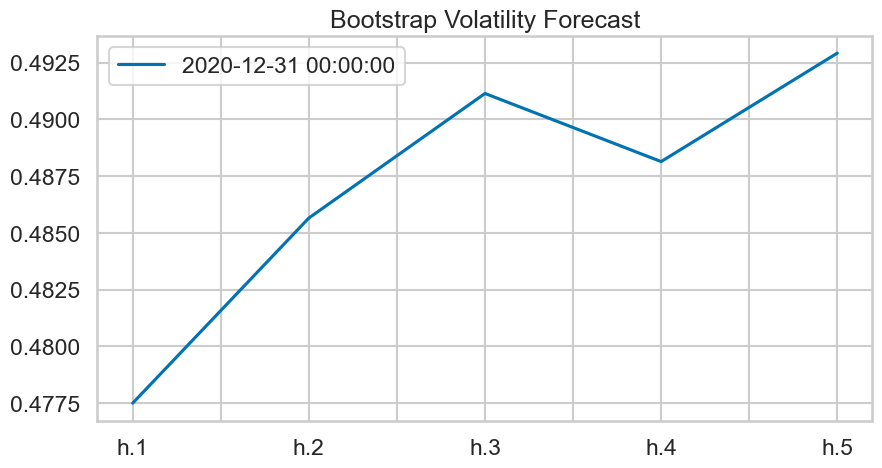

In [47]:
forecast_bootstrap.variance.T.plot(
    figsize=(10,5),
    title="Bootstrap Volatility Forecast"
)

plt.show()

5. Compare the three different methods:

In [48]:
print("Analytical")
print(forecast_analytical.variance.tail())

print("\nSimulation")
print(forecast_simulation.variance.tail())

print("\nBootstrap")
print(forecast_bootstrap.variance.tail())

Analytical
               h.1       h.2       h.3       h.4      h.5
2020-12-31  0.4775  0.482022  0.486486  0.490892  0.49524

Simulation
               h.1      h.2       h.3       h.4       h.5
2020-12-31  0.4775  0.47893  0.481076  0.488516  0.498016

Bootstrap
               h.1       h.2       h.3       h.4       h.5
2020-12-31  0.4775  0.485653  0.491139  0.488139  0.492915
